In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")
data = pd.read_csv('рк1.csv', sep=",")
# Первые 5 строк датасета
unique_cities = data['City'].unique()
data.head()

,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


/tmp/ipykernel_17664/1847991234.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Income'])


<Axes: xlabel='Income', ylabel='Density'>

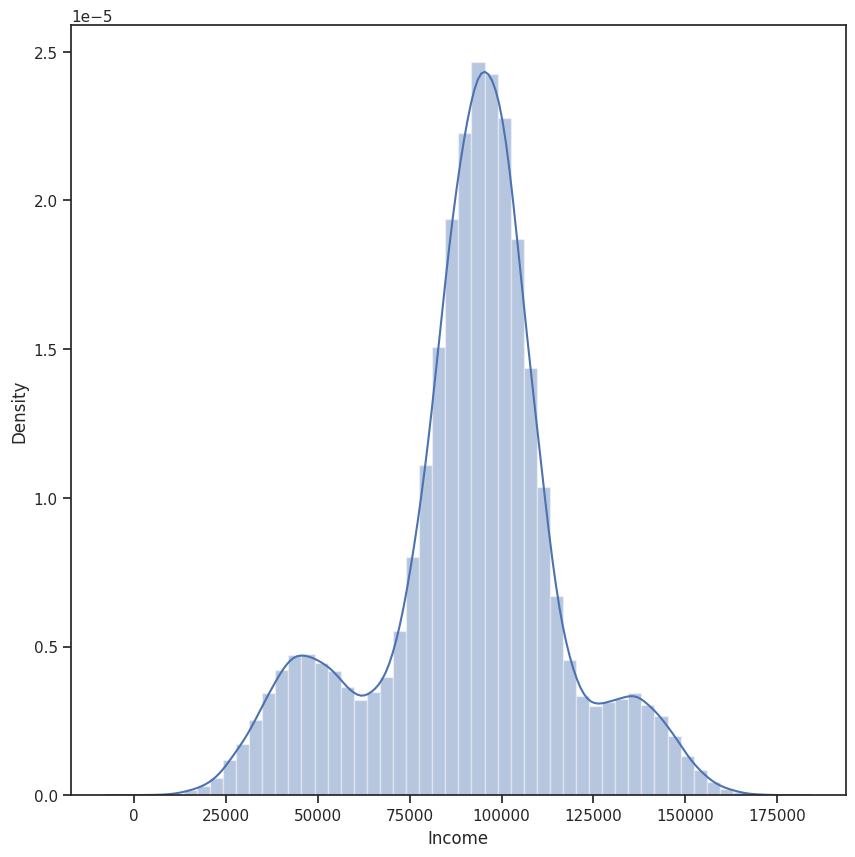

In [64]:
#гистограмма
fig, ax = plt.subplots(figsize=(10,10))
sns.distplot(data['Income'])

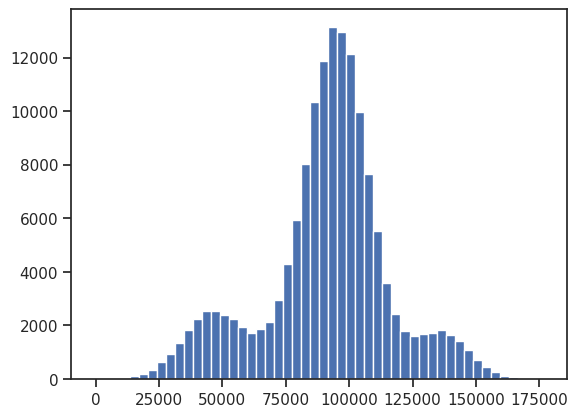

In [42]:
#маштабирование
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer
#MinMax масштабирование
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['Income']])
plt.hist(data['Income'], 50)
plt.show()

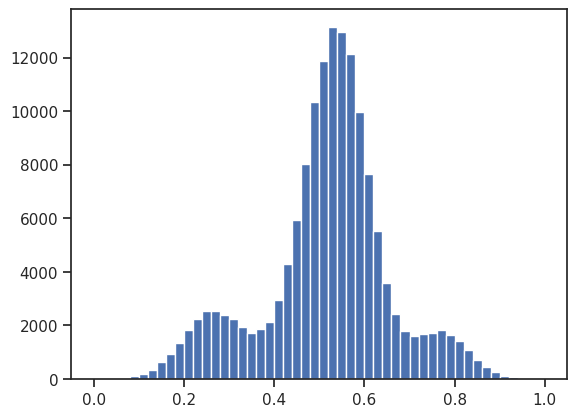

In [43]:
plt.hist(sc1_data, 50)
plt.show()

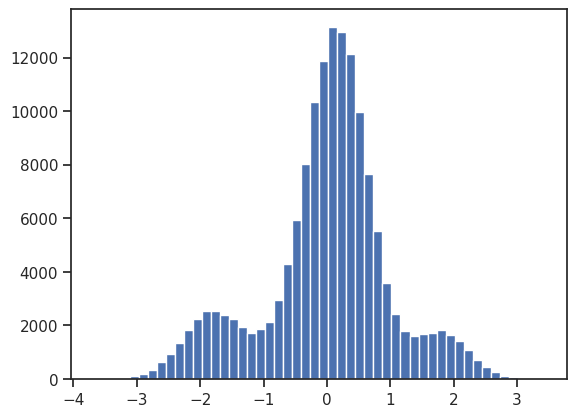

In [44]:
#StandardScaler маштабирование
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['Income']])
plt.hist(sc2_data, 50)
plt.show()

In [45]:
#преобразование категориальных признаков в количественные (label encoding)
from sklearn.preprocessing import LabelEncoder
unique_cities = data['City'].unique()
unique_cities

array(['Dallas', 'New York City', 'Los Angeles', 'Mountain View',
       'Boston', 'Washington D.C.', 'San Diego', 'Austin'], dtype=object)

In [46]:
le = LabelEncoder()
datata = data
datata['City'] = le.fit_transform(datata['City'])
datata.head()

,Number,City,Gender,Age,Income,Illness
0,1,2,Male,41,40367.0,No
1,2,2,Male,54,45084.0,No
2,3,2,Male,42,52483.0,No
3,4,2,Male,40,40941.0,No
4,5,2,Male,46,50289.0,No


In [50]:
np.unique(datata['City'])

array([0, 1, 2, 3, 4, 5, 6, 7])

In [51]:
le.inverse_transform([0, 1, 2, 3, 4, 5, 6, 7])

array(['Austin', 'Boston', 'Dallas', 'Los Angeles', 'Mountain View',
       'New York City', 'San Diego', 'Washington D.C.'], dtype=object)

In [59]:
#преобразование категориальных признаков в количественные (one hot encoding)
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(data[['City']])

,Number,Gender,Age,Income,Illness,City_0,City_1,City_2,City_3,City_4,City_5,City_6,City_7
0,1,Male,41,40367.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,Male,54,45084.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,Male,42,52483.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,Male,40,40941.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,Male,46,50289.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [60]:
cat_enc_ohe.shape

(150000, 8)

In [61]:
cat_enc_ohe[:5]

,City_0,City_1,City_2,City_3,City_4,City_5,City_6,City_7
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [67]:
#искусственные пропуски
data_missing = data.copy()
np.random.seed(42)
mask = np.random.random(len(data_missing)) < 0.1
data_missing.loc[mask, 'Age'] = np.nan
data_missing['Age'].isna().sum()

np.int64(15034)

In [68]:
data_missing.head(20)

,Number,Gender,Age,Income,Illness,City_0,City_1,City_2,City_3,City_4,City_5,City_6,City_7
0,1,Male,41.0,40367.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,Male,54.0,45084.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,3,Male,42.0,52483.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,Male,40.0,40941.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,Male,46.0,50289.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,6,Female,36.0,50786.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,7,Female,NaN,33155.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,8,Male,39.0,30914.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
8,9,Male,51.0,68667.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,10,Female,30.0,50082.0,No,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
